In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

Mounted at /content/drive


In [ ]:
cancels = pd.read_csv("/content/CancelReasons_PJ.csv")
members = pd.read_csv("/content/Staff_Type2_PJ.csv")

In [ ]:
cancels.head()

,Club Name,Agreement #,"Member Name (last, first)",Term,Document Created Date,UDF_AGREEMENTS_019,Member Status,Member Status Reason,UDF_MEMDOCS_040
0,Planet Fitness Clifton Bloomfield Ave NJ,9429612104,"Christian, Kiritkuma",Open,3/29/2023,William Bonilla,Cancelled,Military,NaN
1,Planet Fitness Clifton Bloomfield Ave NJ,9429610956,"French, Kareem",Open,3/29/2023,Allie,Cancelled,Move,NaN
2,Planet Fitness Clifton Bloomfield Ave NJ,9429611006,"Malara, April",Open,3/29/2023,amy vargas,Cancelled,POLICY VIOLATION,NaN
3,Planet Fitness Clifton Bloomfield Ave NJ,9429603941,"Mongare, Timothy",Open,3/29/2023,Dorian Hamilton,Cancelled,CANCEL,NaN
4,Planet Fitness Clifton Bloomfield Ave NJ,9429603028,"Reyes, Delvi",Open,3/29/2023,William Bonilla,Cancelled,Joined Another Club,NaN


In [ ]:
members.head()

,Club Name,Sales Person (first last),Station Location,Agreement #,Member Name (first),Member Name (last),Barcode,Member Status,Membership Type,Member Since Date,Date Signed,Agt Down Payment,First Payment Date,Next Due Amount,Queue Date/Time,Age,Email,Agreement Type,Primary Phone
0,Planet Fitness Clifton Bloomfield Ave NJ,Aiden Hamlin,Club Assisted,9429611021,Al,Dacaj,GUM8Z1BQD1289HR,Cancelled,10NR,2/6/2023,4/3/2023 0:00,5.97,4/17/2023,10.66,4/3/2023 20:18,29,dacajal9@gmail.com,Rewrite,(917) 600-6990
1,Planet Fitness Clifton Bloomfield Ave NJ,Aiden Hamlin,Club Assisted,9429612206,Debbi,Lakritz,BA7QLI2DOD3Z624,Ok,10NR,4/3/2023,4/3/2023 0:00,5.97,4/17/2023,10.66,4/3/2023 12:20,63,dw4435@gmail.com,New Agreement,(414) 217-1558
2,Planet Fitness Clifton Bloomfield Ave NJ,Aiden Hamlin,Club Assisted,9429613755,Rich,Adams,CXTMIGA9Q77DFXR,Ok,10NR,6/26/2023,6/26/2023 0:00,59.60,7/17/2024,10.66,6/26/2023 8:46,36,rjadams113@gmail.com,New Agreement,(201) 407-4123
3,Planet Fitness Clifton Bloomfield Ave NJ,Aiden Hamlin,Club Assisted,9429614048,Edward,Jozak,9737677079,Cancelled,10NR,7/13/2023,7/13/2023 0:00,2.47,7/17/2023,10.66,7/13/2023 8:39,60,edwardjozak445@gmail.com,New Agreement,(973) 767-7079
4,Planet Fitness Clifton Bloomfield Ave NJ,Aiden Hamlin,Club Assisted,9429615039,Kristin,Kaufman,NIN4GWEV9EMNFE5,Cancelled,10NR,9/6/2023,9/6/2023 0:00,4.93,9/17/2023,10.66,9/6/2023 13:00,44,kkaufman222@gmail.com,New Agreement,(973) 818-9755


In [ ]:
cancels.columns

Index(['Club Name', 'Agreement #', 'Member Name (last, first)', 'Term',
       'Document Created Date', 'UDF_AGREEMENTS_019', 'Member Status',
       'Member Status Reason', 'UDF_MEMDOCS_040'],
      dtype='object')

In [ ]:
cancels = cancels[['Agreement #', 'Document Created Date','Member Status Reason']]
cancels

,Agreement #,Document Created Date,Member Status Reason
0,9429612104,3/29/2023,Military
1,9429610956,3/29/2023,Move
2,9429611006,3/29/2023,POLICY VIOLATION
3,9429603941,3/29/2023,CANCEL
4,9429603028,3/29/2023,Joined Another Club
...,...,...,...
7695,9429617331,3/29/2025,Financial Hardship
7696,9429621648,3/29/2025,Joined Another Club
7697,9429624123,3/29/2025,Other Reason
7698,9429626220,3/29/2025,No Time


In [ ]:

merged_df = pd.merge(cancels, members, on=['Agreement #'], how='left')

cancels['age'] = merged_df['Age']

cancels


,Agreement #,Document Created Date,Member Status Reason,age
0,9429612104,3/29/2023,Military,62.0
1,9429610956,3/29/2023,Move,NaN
2,9429611006,3/29/2023,POLICY VIOLATION,NaN
3,9429603941,3/29/2023,CANCEL,NaN
4,9429603028,3/29/2023,Joined Another Club,NaN
...,...,...,...,...
7695,9429617331,3/29/2025,Financial Hardship,24.0
7696,9429621648,3/29/2025,Joined Another Club,55.0
7697,9429624123,3/29/2025,Other Reason,41.0
7698,9429626220,3/29/2025,No Time,37.0


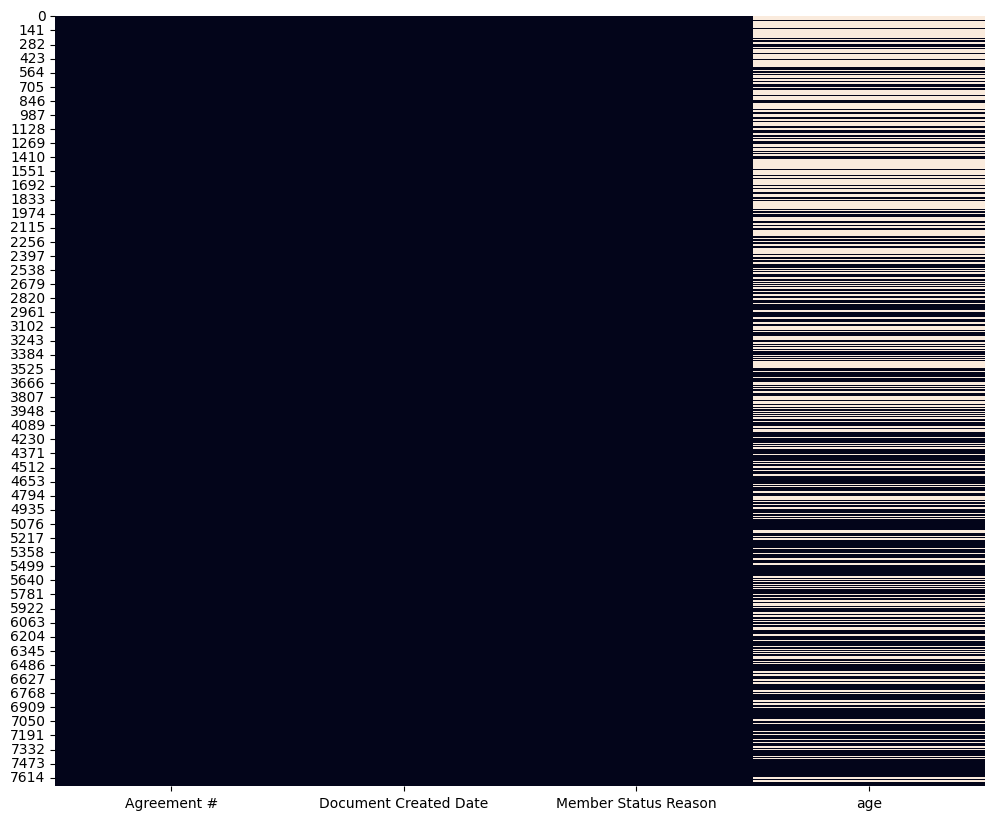

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cancels.isnull(), cbar=False)
plt.show()


In [ ]:
cancels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7700 entries, 0 to 7699
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Agreement #            7700 non-null   int64  
 1   Document Created Date  7700 non-null   object 
 2   Member Status Reason   7700 non-null   object 
 3   age                    4349 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 240.8+ KB


In [ ]:
cancels.dropna(inplace=True)
cancels.info()


<class 'pandas.core.frame.DataFrame'>
Index: 4349 entries, 0 to 7699
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Agreement #            4349 non-null   int64  
 1   Document Created Date  4349 non-null   object 
 2   Member Status Reason   4349 non-null   object 
 3   age                    4349 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 169.9+ KB


In [ ]:
print(cancels['age'].mean())

33.05564497585652


In [ ]:
cancels['age group'] = cancels['age']
cancels['age group'] = [
    "<20" if i < 20
    else "20s" if i < 30
    else "30s" if i < 40
    else "40s" if i < 50
    else "50s" if i < 60
    else ">60"
    for i in cancels['age']
]


In [ ]:
cancels

,Agreement #,Document Created Date,Member Status Reason,age,age group
0,9429612104,3/29/2023,Military,62.0,>60
5,9429607635,3/29/2023,Move,44.0,40s
6,9429612108,3/29/2023,CANCEL,17.0,<20
7,9429612108,3/29/2023,CANCEL,17.0,<20
8,9429612108,3/29/2023,CANCEL,17.0,<20
...,...,...,...,...,...
7695,9429617331,3/29/2025,Financial Hardship,24.0,20s
7696,9429621648,3/29/2025,Joined Another Club,55.0,50s
7697,9429624123,3/29/2025,Other Reason,41.0,40s
7698,9429626220,3/29/2025,No Time,37.0,30s


In [ ]:
cancels = cancels[cancels['Member Status Reason'] != 'POLICY VIOLATION']


# Age Group

In [ ]:
cancels['age group'].value_counts()

,count
age group,
20s,1754
30s,925
40s,515
<20,496
50s,404
>60,248


In [ ]:
members['age group'] = members['Age']
members['age group'] = [
    "<20" if i < 20
    else "20s" if i < 30
    else "30s" if i < 40
    else "40s" if i < 50
    else "50s" if i < 60
    else ">60"
    for i in members['Age']
]


In [ ]:
members['age group'].value_counts()

,count
age group,
20s,4056
30s,2474
40s,1395
<20,1146
50s,927
>60,790


In [ ]:

age_group = pd.DataFrame({
    'cancels': cancels['age group'].value_counts(),
    'population': members['age group'].value_counts()
})
age_group


,cancels,population
age group,,
20s,1754,4056
30s,925,2474
40s,515,1395
<20,496,1146
50s,404,927
>60,248,790


In [ ]:
age_group['percentage'] = (age_group['cancels'] / age_group['population']) * 100
age_group = age_group.sort_values(by='percentage', ascending=False)

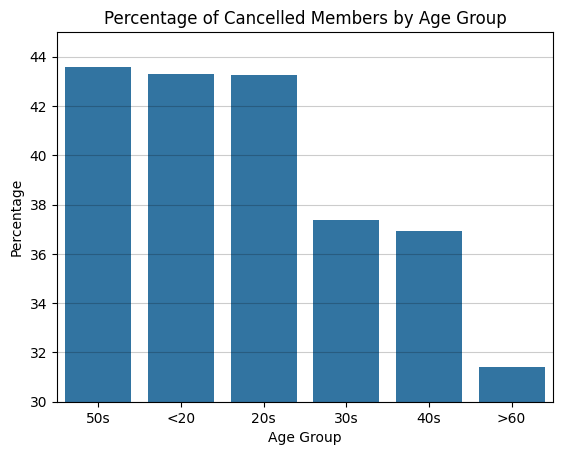

In [ ]:
plt.figure()
sns.barplot(x=age_group.index, y=age_group['percentage'])
plt.title('Percentage of Cancelled Members by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Percentage')
plt.ylim(30, 45)
plt.grid(True, axis = 'y', color = 'black', alpha = 0.2)
plt.show()

# prediction based on age group

In [ ]:
cancels.head(
)

,Agreement #,Document Created Date,Member Status Reason,age,age group
0,9429612104,3/29/2023,Military,62.0,>60
5,9429607635,3/29/2023,Move,44.0,40s
6,9429612108,3/29/2023,CANCEL,17.0,<20
7,9429612108,3/29/2023,CANCEL,17.0,<20
8,9429612108,3/29/2023,CANCEL,17.0,<20


In [ ]:
# prompt: make age and Age the same column under new df

# Rename the 'Age' column in the 'members' DataFrame to 'age'
members = members.rename(columns={'Age': 'age'})

# Now, both 'cancels' and 'members' DataFrames have an 'age' column.
# The merge operation will now work correctly.
merged_df = pd.merge(cancels, members, on=['Agreement #', 'age'], how='left')

# ... (rest of your code)


In [ ]:
new_df = pd.concat([cancels, members])
new_df = new_df.drop_duplicates(subset=['Agreement #'])
new_df['Member Status Reason'].fillna('Active', inplace=True)

new_df = new_df[['Agreement #', 'age','age group', 'Member Status Reason']]

new_df


<ipython-input-20-83a68a7e0f29>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  new_df['Member Status Reason'].fillna('Active', inplace=True)


,Agreement #,age,age group,Member Status Reason
0,9429612104,62.0,>60,Military
5,9429607635,44.0,40s,Move
6,9429612108,17.0,<20,CANCEL
9,9429612096,32.0,30s,CANCEL
13,9429612120,20.0,20s,No Time
...,...,...,...,...
10783,9429624544,33.0,30s,Active
10784,9429624545,37.0,30s,Active
10785,9429625015,21.0,20s,Active
10786,9429626129,55.0,50s,Active


In [ ]:
# prompt: if there is null values in age group in new df, label them under the previous code under their respective age group

# Fill NaN values in 'age group' based on the 'age' column
new_df.loc[new_df['age group'].isnull(), 'age group'] = [
    "<20" if i < 20
    else "20s" if i < 30
    else "30s" if i < 40
    else "40s" if i < 50
    else "50s" if i < 60
    else ">60"
    for i in new_df.loc[new_df['age group'].isnull(), 'age']
]

new_df


,Agreement #,age,age group,Member Status Reason
0,9429612104,62.0,>60,Military
5,9429607635,44.0,40s,Move
6,9429612108,17.0,<20,CANCEL
9,9429612096,32.0,30s,CANCEL
13,9429612120,20.0,20s,No Time
...,...,...,...,...
10783,9429624544,33.0,30s,Active
10784,9429624545,37.0,30s,Active
10785,9429625015,21.0,20s,Active
10786,9429626129,55.0,50s,Active


In [ ]:
# prompt: add Member Since Date and member ship type from members df into new df based on agreement number matching

# Assuming 'members' DataFrame has columns 'Agreement #', 'Member Since Date', and 'Membership Type'

# Create a dictionary to map 'Agreement #' to 'Member Since Date' and 'Membership Type'
member_info = members.set_index('Agreement #')[['Member Since Date', 'Membership Type', 'Agt Down Payment']].to_dict('index')

# Function to get member info based on agreement number
def get_member_info(agreement_num):
    if agreement_num in member_info:
        return member_info[agreement_num]
    else:
        return {'Member Since Date': None, 'Membership Type': None}  # Or handle missing data as needed


# Apply the function to create new columns in 'new_df'
new_df['Member Since Date'] = new_df['Agreement #'].apply(lambda x: get_member_info(x)['Member Since Date'])
new_df['Membership Type'] = new_df['Agreement #'].apply(lambda x: get_member_info(x)['Membership Type'])

new_df


,Agreement #,age,age group,Member Status Reason,Member Since Date,Membership Type
0,9429612104,62.0,>60,Military,3/29/2023,Black Card+
5,9429607635,44.0,40s,Move,9/7/2022,10NR
6,9429612108,17.0,<20,CANCEL,3/29/2023,10NR
9,9429612096,32.0,30s,CANCEL,3/29/2023,Black Card+
13,9429612120,20.0,20s,No Time,3/30/2023,Black Card+
...,...,...,...,...,...,...
10783,9429624544,33.0,30s,Active,1/3/2025,Silver and Fit
10784,9429624545,37.0,30s,Active,1/3/2025,Silver and Fit
10785,9429625015,21.0,20s,Active,1/20/2025,Silver and Fit
10786,9429626129,55.0,50s,Active,3/14/2025,Silver and Fit


In [ ]:
new_df.info(
)

<class 'pandas.core.frame.DataFrame'>
Index: 10788 entries, 0 to 10787
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Agreement #           10788 non-null  int64  
 1   age                   10788 non-null  float64
 2   age group             10788 non-null  object 
 3   Member Status Reason  10788 non-null  object 
 4   Member Since Date     10788 non-null  object 
 5   Membership Type       10788 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 848.0+ KB


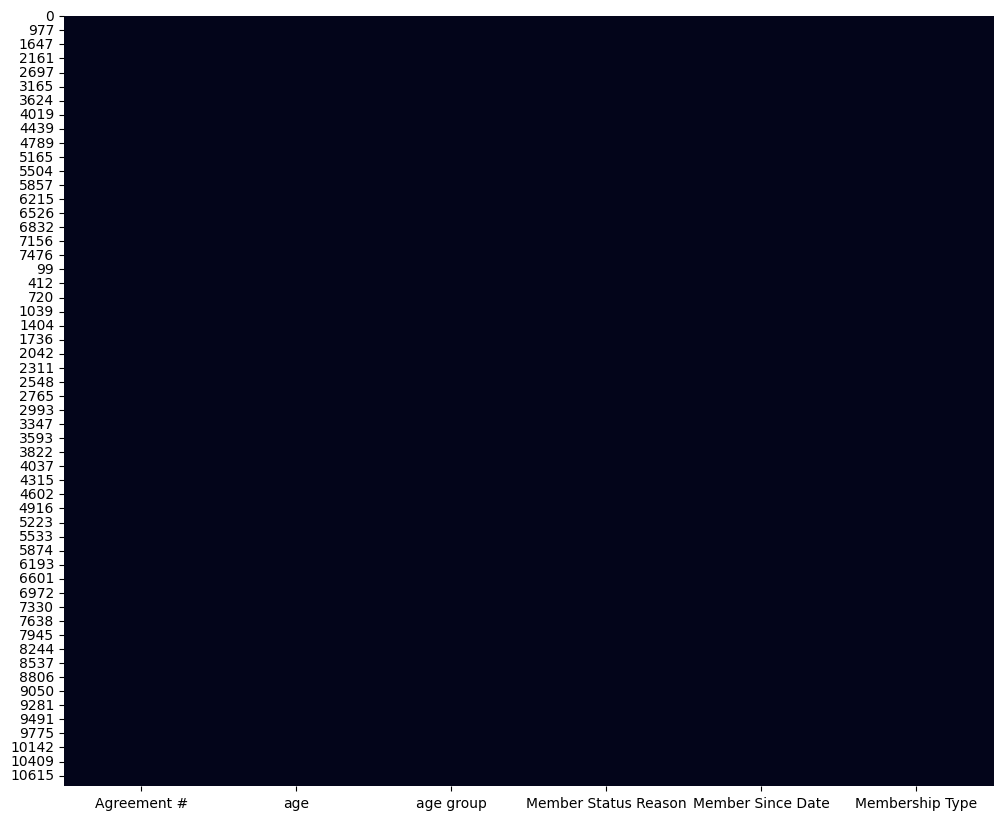

In [ ]:
# prompt: visualize the null values in new_df

plt.figure(figsize=(12, 10))
sns.heatmap(new_df.isnull(), cbar=False)
plt.show()


In [ ]:
# prompt: make everything that isnt active under member status reason is cancelled

# Assuming 'members' DataFrame has columns 'Agreement #', 'Member Since Date', and 'Membership Type'

# Create a dictionary to map 'Agreement #' to 'Member Since Date' and 'Membership Type'
member_info = members.set_index('Agreement #')[['Member Since Date', 'Membership Type']].to_dict('index')

# Function to get member info based on agreement number
def get_member_info(agreement_num):
    if agreement_num in member_info:
        return member_info[agreement_num]
    else:
        return {'Member Since Date': None, 'Membership Type': None}  # Or handle missing data as needed


# Apply the function to create new columns in 'new_df'
new_df['Member Since Date'] = new_df['Agreement #'].apply(lambda x: get_member_info(x)['Member Since Date'])
new_df['Membership Type'] = new_df['Agreement #'].apply(lambda x: get_member_info(x)['Membership Type'])

# Update 'Member Status Reason' for inactive members
new_df.loc[new_df['Member Status Reason'] != 'Active', 'Member Status Reason'] = 'Cancelled'

new_df


,Agreement #,age,age group,Member Status Reason,Member Since Date,Membership Type
0,9429612104,62.0,>60,Cancelled,3/29/2023,Black Card+
5,9429607635,44.0,40s,Cancelled,9/7/2022,10NR
6,9429612108,17.0,<20,Cancelled,3/29/2023,10NR
9,9429612096,32.0,30s,Cancelled,3/29/2023,Black Card+
13,9429612120,20.0,20s,Cancelled,3/30/2023,Black Card+
...,...,...,...,...,...,...
10783,9429624544,33.0,30s,Active,1/3/2025,Silver and Fit
10784,9429624545,37.0,30s,Active,1/3/2025,Silver and Fit
10785,9429625015,21.0,20s,Active,1/20/2025,Silver and Fit
10786,9429626129,55.0,50s,Active,3/14/2025,Silver and Fit


In [ ]:
# prompt: include station location and Agt Down Payment from members df in new_df

# Assuming 'members' DataFrame has columns 'Agreement #', 'Station Location', and 'Agt Down Payment'

# Create a dictionary to map 'Agreement #' to 'Station Location' and 'Agt Down Payment'
member_info = members.set_index('Agreement #')[['Station Location', 'Agreement Type']].to_dict('index')

# Function to get member info based on agreement number
def get_member_info(agreement_num):
    if agreement_num in member_info:
        return member_info[agreement_num]
    else:
        return {'Station Location': None, 'Agreement Type': None}  # Or handle missing data as needed

# Apply the function to create new columns in 'new_df'
new_df['Station Location'] = new_df['Agreement #'].apply(lambda x: get_member_info(x)['Station Location'])
new_df['Agreement Type'] = new_df['Agreement #'].apply(lambda x: get_member_info(x)['Agreement Type'])


In [ ]:
new_df['Membership Type'].value_counts()

,count
Membership Type,
Black Card+,6531
10NR,3693
10SP,142
10SS,120
Silver and Fit,108
BCCOMP,57
BCSP,55
BCMSS,33
BCEMP,21


In [ ]:
# prompt: combine black card member with black card+ and make it just black card, also only keep 10nr and the new combine black card

# Replace 'Black Card+' and 'Black Card Member' with 'Black Card' in 'Membership Type' column
new_df['Membership Type'] = new_df['Membership Type'].replace(['Black Card+', 'Black Card Member'], 'Black Card')

# Keep only '10NR' and 'Black Card' membership types
new_df = new_df[new_df['Membership Type'].isin(['10NR', 'Black Card'])]

# Display the updated DataFrame
new_df


,Agreement #,age,age group,Member Status Reason,Member Since Date,Membership Type,Station Location,Agreement Type
0,9429612104,62.0,>60,Cancelled,3/29/2023,Black Card,NaN,New Agreement
5,9429607635,44.0,40s,Cancelled,9/7/2022,10NR,Club Assisted,Rewrite
6,9429612108,17.0,<20,Cancelled,3/29/2023,10NR,NaN,New Agreement
9,9429612096,32.0,30s,Cancelled,3/29/2023,Black Card,NaN,New Agreement
13,9429612120,20.0,20s,Cancelled,3/30/2023,Black Card,NaN,New Agreement
...,...,...,...,...,...,...,...,...
10674,9429622632,32.0,30s,Active,5/13/2019,Black Card,NaN,Rewrite
10675,9429606561,47.0,40s,Active,2/17/2021,Black Card,NaN,Rewrite
10676,9429604417,48.0,40s,Active,3/1/2016,Black Card,NaN,Rewrite
10677,9429605032,40.0,40s,Active,2/29/2016,Black Card,NaN,Rewrite


In [ ]:
new_df['Membership Type'].value_counts()

,count
Membership Type,
Black Card,6531
10NR,3693


In [ ]:
# prompt: make a new column in new_df where you get all the characters before the first / and name the column month

new_df['month'] = new_df['Member Since Date'].str.split('/').str[0]


<ipython-input-28-29156dbba062>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['month'] = new_df['Member Since Date'].str.split('/').str[0]


In [ ]:
# prompt: import decision tree classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelBinarizer # Import LabelBinarizer

# Prepare the data for the decision tree classifier
X = new_df[['age group', 'Membership Type', "Station Location", 'Agreement Type']]
y = new_df['Member Status Reason']

X = pd.get_dummies(X, columns=['age group', 'Membership Type', "Station Location", 'Agreement Type'], drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize and train the decision tree classifier
clf = DecisionTreeClassifier()  # You can adjust hyperparameters here
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Convert y_test and y_pred to binary format for roc_auc_score
lb = LabelBinarizer() # Create a LabelBinarizer object
y_test_binary = lb.fit_transform(y_test) # Fit and transform y_test
y_pred_binary = lb.transform(y_pred) # Transform y_pred using the same binarizer

# Calculate ROC AUC score for binary classification
roc_auc = roc_auc_score(y_test_binary, y_pred_binary) # Use binary labels for roc_auc_score


print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)
print(f"ROC AUC Score: {roc_auc}")

Accuracy: 0.6665036674816626
Confusion Matrix:
[[1359    6]
 [ 676    4]]
Classification Report:
              precision    recall  f1-score   support

      Active       0.67      1.00      0.80      1365
   Cancelled       0.40      0.01      0.01       680

    accuracy                           0.67      2045
   macro avg       0.53      0.50      0.41      2045
weighted avg       0.58      0.67      0.54      2045

ROC AUC Score: 0.500743374272786


In [ ]:
# prompt: import KNN with optimal K to predict Y

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Assuming X and y are already defined as in the previous code
# X = new_df[['age group', 'Membership Type', "Station Location"]]  # Features
# y = new_df['Member Status Reason'] # Target variable
# X = pd.get_dummies(X, columns= ['age group', 'Membership Type', "Station Location"], drop_first=True)

# Split data into training and testing sets (if not already split)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Use random_state for reproducibility

# Finding optimal k
k_values = list(range(1, 60))
cv_scores = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='roc_auc_ovr') # 5-fold cross-validation
  cv_scores.append(scores.mean())

optimal_k = k_values[cv_scores.index(max(cv_scores))]
print(f"Optimal k: {optimal_k}")

# Train KNN with optimal k
knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k)
knn_optimal.fit(X_train, y_train)

# Make predictions
y_pred = knn_optimal.predict(X_test)

# Convert y_test and y_pred to binary format for roc_auc_score
lb = LabelBinarizer() # Create a LabelBinarizer object
y_test_binary = lb.fit_transform(y_test) # Fit and transform y_test
y_pred_binary = lb.transform(y_pred) # Transform y_pred using the same binarizer

# Calculate ROC AUC score for binary classification
roc_auc = roc_auc_score(y_test_binary, y_pred_binary) # Use binary labels for roc_auc_score


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy with optimal k: {accuracy}")
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(roc_auc_score(y_test_binary, y_pred_binary))


Optimal k: 14
Accuracy with optimal k: 0.652322738386308
              precision    recall  f1-score   support

      Active       0.68      0.92      0.78      1365
   Cancelled       0.42      0.12      0.18       680

    accuracy                           0.65      2045
   macro avg       0.55      0.52      0.48      2045
weighted avg       0.59      0.65      0.58      2045

[[1254  111]
 [ 600   80]]
0.518164188752424


In [ ]:
# prompt: import xgb boost to predict y

!pip install xgboost
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Assuming X and y are already defined as in the previous code
X = new_df[['age group', 'Membership Type', "Station Location",'Agreement Type']]  # Features
y = new_df['Member Status Reason'] # Target variable
#X = pd.get_dummies(X, columns=['age group', 'Membership Type', "Station Location"], drop_first=True) # This line is causing the error
X_encoded = pd.get_dummies(X, columns=['age group', 'Membership Type', "Station Location",'Agreement Type'], drop_first=True)


# ---> Replace any invalid characters in column names
# This regex replaces any characters that are not alphanumeric or underscore with an underscore
X_encoded.columns = X_encoded.columns.str.replace('[^a-zA-Z0-9_]', '_', regex=True)

# Split data into training and testing sets (if not already split)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Use random_state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.3)


# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the target variable
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Create DMatrix for XGBoost with encoded labels
dtrain = xgb.DMatrix(X_train, label=y_train_encoded)
dtest = xgb.DMatrix(X_test, label=y_test_encoded)

# Set XGBoost parameters
params = {
    'objective': 'multi:softmax',  # For multi-class classification
    'num_class': len(y.unique()),  # Number of classes
    'eval_metric': 'merror',  # Use multi-class error rate
    'eta': 0.1,  # Learning rate
    'max_depth': 6,  # Maximum depth of the trees
    'subsample': 0.8, # Subsample ratio of the training instances
    'colsample_bytree': 0.8 # Subsample ratio of columns when constructing each tree
}

# Train the XGBoost model
num_rounds = 100 # Number of boosting rounds
model = xgb.train(params, dtrain, num_rounds)

# Make predictions
y_pred_encoded = model.predict(dtest)

# Inverse transform the predictions to get original labels
y_pred = le.inverse_transform(y_pred_encoded.astype(int))


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

XGBoost Accuracy: 0.652542372881356
              precision    recall  f1-score   support

      Active       0.65      1.00      0.79      2003
   Cancelled       0.00      0.00      0.00      1065

    accuracy                           0.65      3068
   macro avg       0.33      0.50      0.39      3068
weighted avg       0.43      0.65      0.52      3068



In [ ]:
# prompt: import random forest and predict

from sklearn.ensemble import RandomForestClassifier

# Assuming X and y are already defined as in the previous code
X = new_df[['age group', 'Membership Type', "Station Location", 'Agreement Type']]  # Features
y = new_df['Member Status Reason'] # Target variable
X = pd.get_dummies(X, columns=['age group', 'Membership Type', "Station Location",'Agreement Type'], drop_first=True)

# Split data into training and testing sets (if not already split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) # Use random_state for reproducibility

# Initialize and train a RandomForestClassifier
rf_classifier = RandomForestClassifier(n_estimators=100, criterion= 'log_loss') # You can adjust n_estimators and other hyperparameters
rf_classifier.fit(X_train, y_train)

# Make predictions
y_pred = rf_classifier.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.6562347188264058
              precision    recall  f1-score   support

      Active       0.66      1.00      0.79      1344
   Cancelled       0.25      0.00      0.00       701

    accuracy                           0.66      2045
   macro avg       0.45      0.50      0.40      2045
weighted avg       0.52      0.66      0.52      2045



In [ ]:
# prompt: import boosted tree classifier to predict y

# Assuming X_encoded, y, and the necessary imports are already defined as in the previous code.

# Split data into training and testing sets (if not already split)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42) # Use random_state for reproducibility

# Initialize LabelEncoder
le = LabelEncoder()

# Fit and transform the target variable
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


# Initialize and train the boosted tree classifier (XGBoost)
model = xgb.XGBClassifier(objective='multi:softmax', num_class=len(np.unique(y_train_encoded)), random_state=42)
model.fit(X_train, y_train_encoded)

# Make predictions
y_pred_encoded = model.predict(X_test)

# Inverse transform the predictions
y_pred = le.inverse_transform(y_pred_encoded)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Boosted Tree Classifier (XGBoost) Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Boosted Tree Classifier (XGBoost) Accuracy: 0.6557457212713936
              precision    recall  f1-score   support

      Active       0.66      0.99      0.79      1347
   Cancelled       0.25      0.00      0.01       698

    accuracy                           0.66      2045
   macro avg       0.45      0.50      0.40      2045
weighted avg       0.52      0.66      0.52      2045



In [ ]:
# prompt: import logistic regression and predict y

from sklearn.linear_model import LogisticRegression

# Assuming X_encoded and y are already defined as in the previous code.
X = new_df[['age group', 'Membership Type', "Station Location", 'Agreement Type']]  # Features
y = new_df['Member Status Reason'] # Target variable
X = pd.get_dummies(X, columns=['age group', 'Membership Type', "Station Location", 'Agreement Type'], drop_first=True)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Initialize and train the Logistic Regression model
logreg_model = LogisticRegression(multi_class='ovr', random_state=42) # Increased max_iter
logreg_model.fit(X_train, y_train)

# Make predictions
y_pred = logreg_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.6562347188264058
              precision    recall  f1-score   support

      Active       0.66      1.00      0.79      1343
   Cancelled       0.00      0.00      0.00       702

    accuracy                           0.66      2045
   macro avg       0.33      0.50      0.40      2045
weighted avg       0.43      0.66      0.52      2045



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Assuming X_encoded and y are already defined and preprocessed as in the previous code.
# Example:
X = new_df[['age group', 'Membership Type', 'Station Location', 'Agreement Type']]
y = new_df['Member Status Reason']
X = pd.get_dummies(X, columns=['age group', 'Membership Type', 'Station Location', 'Agreement Type'], drop_first=True)

# Assuming X and y are already defined
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)



# Convert y to numerical labels using LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Define the ANN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
# Use 'categorical_crossentropy' for one-hot encoded labels, and 'sparse_categorical_crossentropy' for integer labels
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # Replace 'AUC' with 'accuracy' for multi-class

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Make predictions
y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1) # Get predicted class labels

# Inverse transform the predictions to original labels
y_pred = le.inverse_transform(y_pred)
y_test = le.inverse_transform(y_test)


import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model (example metrics)
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

NameError: name 'y_encoded' is not defined

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6574 - loss: 0.6454 - val_accuracy: 0.6812 - val_loss: 0.6219
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6631 - loss: 0.6360 - val_accuracy: 0.6812 - val_loss: 0.6243
Epoch 3/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6718 - loss: 0.6308 - val_accuracy: 0.6812 - val_loss: 0.6258
Epoch 4/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6641 - loss: 0.6357 - val_accuracy: 0.6812 - val_loss: 0.6199
Epoch 5/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6681 - loss: 0.6300 - val_accuracy: 0.6812 - val_loss: 0.6194
Epoch 6/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6695 - loss: 0.6305 - val_accuracy: 0.6817 - val_loss: 0.6210
Epoch 7/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6652 - loss: 0.6315 - val_accuracy: 0.6812 - val_loss: 0.6209
Epoch 8/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6568 - loss: 0.6409 - val_acc

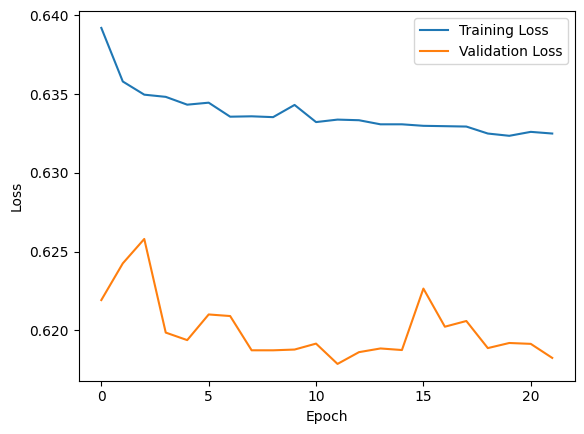

ANN Accuracy: 0.6572127139364303
              precision    recall  f1-score   support

      Active       0.66      1.00      0.79      1347
   Cancelled       0.20      0.00      0.00       698

    accuracy                           0.66      2045
   macro avg       0.43      0.50      0.40      2045
weighted avg       0.50      0.66      0.52      2045



In [ ]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Assuming X_encoded and y are already defined and preprocessed as in the previous code.
# Example:
X = new_df[['age group', 'Membership Type', 'Station Location', 'Agreement Type']]
y = new_df['Member Status Reason']
X = pd.get_dummies(X, columns=['age group', 'Membership Type', 'Station Location', 'Agreement Type'], drop_first=True)

# Convert y to numerical labels using LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Define y_encoded here by transforming y

# Assuming X and y are already defined
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)  # 0.25 x 0.8 = 0.2

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)



# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Define the ANN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
# Use 'categorical_crossentropy' for one-hot encoded labels, and 'sparse_categorical_crossentropy' for integer labels
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy']) # Replace 'AUC' with 'accuracy' for multi-class

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_val, y_val), callbacks=[early_stopping])

# Make predictions
y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1) # Get predicted class labels

# Inverse transform the predictions to original labels
y_pred = le.inverse_transform(y_pred)
y_test = le.inverse_transform(y_test)


import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluate the model (example metrics)
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

In [ ]:
# prompt: accurately predict y

# Assuming X_encoded and y are already defined as in the previous code.
# Example:
X = new_df[['age group', 'Membership Type', 'Station Location']]
y = new_df['Member Status Reason']
X = pd.get_dummies(X, columns=['age group', 'Membership Type', 'Station Location'], drop_first=True)

# Convert y to numerical labels using LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Define the ANN model
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax') # Output layer with softmax for multi-class
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=100, validation_split=0.2, callbacks=[early_stopping])

# Make predictions
y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Inverse transform the predictions to original labels
y_pred = le.inverse_transform(y_pred)
y_test = le.inverse_transform(y_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6555 - loss: 0.6457 - val_accuracy: 0.6632 - val_loss: 0.6351
Epoch 2/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6656 - loss: 0.6364 - val_accuracy: 0.6632 - val_loss: 0.6334
Epoch 3/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6604 - loss: 0.6398 - val_accuracy: 0.6632 - val_loss: 0.6351
Epoch 4/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6673 - loss: 0.6330 - val_accuracy: 0.6632 - val_loss: 0.6339
Epoch 5/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6658 - loss: 0.6356 - val_accuracy: 0.6632 - val_loss: 0.6336
Epoch 6/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6601 - loss: 0.6400 - val_accuracy: 0.6632 - val_loss: 0.6332
Epoch 7/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6644 - loss: 0.6367 - val_accuracy: 0.6626 - val_loss: 0.6332
Epoch 8/100
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6660 - loss: 0.6331 - val_accuracy: 0.6632

In [ ]:
# prompt: use a classification model that would give me over .85 accuracy for predicting y

# Assuming X_encoded and y are already defined as in the previous code.
# Example:
X = new_df[['age group', 'Membership Type', 'Station Location']]
y = new_df['Member Status Reason']
X = pd.get_dummies(X, columns=['age group', 'Membership Type', 'Station Location'], drop_first=True)

# Convert y to numerical labels using LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Define the ANN model with increased complexity
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),  # Add dropout for regularization
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with early stopping and increased epochs
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True) # Increased patience
history = model.fit(X_train, y_train, epochs=200, validation_split=0.2, callbacks=[early_stopping]) # Increased epochs

# Make predictions
y_pred_probabilities = model.predict(X_test)
y_pred = np.argmax(y_pred_probabilities, axis=1)

# Inverse transform the predictions to original labels
y_pred = le.inverse_transform(y_pred)
y_test = le.inverse_transform(y_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"ANN Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


Epoch 1/200


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6373 - loss: 0.6577 - val_accuracy: 0.6632 - val_loss: 0.6351
Epoch 2/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6760 - loss: 0.6322 - val_accuracy: 0.6632 - val_loss: 0.6355
Epoch 3/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6714 - loss: 0.6322 - val_accuracy: 0.6632 - val_loss: 0.6371
Epoch 4/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6686 - loss: 0.6358 - val_accuracy: 0.6632 - val_loss: 0.6348
Epoch 5/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6666 - loss: 0.6345 - val_accuracy: 0.6632 - val_loss: 0.6365
Epoch 6/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6605 - loss: 0.6403 - val_accuracy: 0.6632 - val_loss: 0.6345
Epoch 7/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6574 - loss: 0.6414 - val_accuracy: 0.6632 - val_loss: 0.6346
Epoch 8/200
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6485 - loss: 0.6443 - val_accuracy: 0.6632

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Assuming 'new_df' is your DataFrame
X = new_df[['age group', 'Membership Type', 'Station Location', 'Agreement Type']]  # Features
y = new_df['Member Status Reason']  # Target variable

# Convert categorical features to numerical using Label Encoding
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Decision Tree Classifier with hyperparameters
clf = DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42)
# Adjust hyperparameters as needed

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Decision Tree Accuracy: 0.6596577017114914
              precision    recall  f1-score   support

      Active       0.66      0.98      0.79      1347
   Cancelled       0.52      0.03      0.06       698

    accuracy                           0.66      2045
   macro avg       0.59      0.51      0.43      2045
weighted avg       0.61      0.66      0.54      2045



<ipython-input-46-4392e630f91b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-46-4392e630f91b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-46-4392e630f91b>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

# Adding times checked in within 3 months

In [ ]:
check_in = pd.read_csv('/content/CancelReasons_PJ.csv')

In [ ]:
# prompt: add a new column to new_df where it counts how many times the agreement number shows up in check_in

# Assuming 'new_df' and 'check_in' are already loaded as pandas DataFrames

# Merge the two dataframes on 'Agreement Number'
merged_df = pd.merge(new_df, check_in, on='Agreement #', how='left')

# Group by 'Agreement #' and count occurrences (size of each group)
times_checked_in = merged_df.groupby('Agreement #').size().reset_index(name='times_checked_in')

# Merge the counts back into new_df
new_df = pd.merge(new_df, times_checked_in, on='Agreement #', how='left')

# Fill potential NaN values with 0
new_df['times_checked_in'] = new_df['times_checked_in'].fillna(0).astype(int)

In [ ]:
new_df.head()

,Agreement #,age,age group,Member Status Reason,Member Since Date,Membership Type,Station Location,Agreement Type,month,times_checked_in
0,9429612104,62.0,>60,Cancelled,3/29/2023,Black Card,NaN,New Agreement,3,2
1,9429607635,44.0,40s,Cancelled,9/7/2022,10NR,Club Assisted,Rewrite,9,2
2,9429612108,17.0,<20,Cancelled,3/29/2023,10NR,NaN,New Agreement,3,6
3,9429612096,32.0,30s,Cancelled,3/29/2023,Black Card,NaN,New Agreement,3,2
4,9429612120,20.0,20s,Cancelled,3/30/2023,Black Card,NaN,New Agreement,3,3


In [ ]:
new_df['times_checked_in'].min()

1

In [ ]:
# prompt: import decision tree and use age group, membership type, agt down payment, month, agreement type, and times_checked_in to predict member status reason

# Assuming 'new_df' is your DataFrame and it includes the 'times_checked_in' column
X = new_df[['age group', 'Membership Type', 'times_checked_in']]
y = new_df['Member Status Reason']

# Convert categorical features to numerical using Label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

# Handle missing values (if any) - replace with the mean for numerical features
# X = X.fillna(X.mean()) # Or fill with a specific value, median, or use imputation methods

# Split data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize the Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)  # You can adjust hyperparameters here

# Train the classifier
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate the model
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))


<ipython-input-33-9ed6f1a95198>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
<ipython-input-33-9ed6f1a95198>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])


Decision Tree Accuracy: 0.71251629726206
              precision    recall  f1-score   support

      Active       0.69      1.00      0.82      2005
   Cancelled       1.00      0.17      0.29      1063

    accuracy                           0.71      3068
   macro avg       0.85      0.59      0.56      3068
weighted avg       0.80      0.71      0.64      3068



In [ ]:
new_df.head()

,Agreement #,age,age group,Member Status Reason,Member Since Date,Membership Type,Station Location,Agreement Type,month,times_checked_in
0,9429612104,62.0,>60,Cancelled,3/29/2023,Black Card,NaN,New Agreement,3,2
1,9429607635,44.0,40s,Cancelled,9/7/2022,10NR,Club Assisted,Rewrite,9,2
2,9429612108,17.0,<20,Cancelled,3/29/2023,10NR,NaN,New Agreement,3,6
3,9429612096,32.0,30s,Cancelled,3/29/2023,Black Card,NaN,New Agreement,3,2
4,9429612120,20.0,20s,Cancelled,3/30/2023,Black Card,NaN,New Agreement,3,3


In [ ]:
PF_data = new_df

In [ ]:
PF_data.to_csv('PF_data.csv')